In [120]:
#neurokit permite simular señales sintéticas
#en eeg pueden probar y colocar spikes aleatorios
#6 ejercicios
#usar api de scipy

In [121]:
!pip install neurokit2

In [122]:
import neurokit2 as nk
#Ejercicio 1
#ecg1=nk.ecg_simulate(duration=10, length=None, sampling_rate=1000, noise=0.01, heart_rate=1200, heart_rate_std=1, method='ecgsyn', random_state=None)

In [123]:
!pip install git+https://github.com/MSMRo/signalDraw-isb.git
from signaldraw_isb import SignalDraw

  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-zxyubzwl
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-zxyubzwl
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Señales obtenidas por signalDraw de 5 Hz (fs= 1000 Hz, Offset=0.0, Amplitud=0.4, Tiempo= 0-10s) y 80 Hz (fs= 1000 Hz, Offset=0.6, Amplitud=0.8, Tiempo= 0-10s)

In [124]:
!pip install scipy
import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np

fs=1000
t = np.linspace(0, 10, fs*10, endpoint=False)
f1 = 5
offset1 = 0.0
amp1 = 0.4
noise1 = offset1 + amp1 * np.sin(2 * np.pi * f1 * t)

f2 = 80
offset2 = 0.6
amp2 = 0.8
noise2 = offset2 + amp2 * np.sin(2 * np.pi * f2 * t)
ecg1=np.sin(2 * np.pi * 20 * t)
signal1=ecg1+noise1+noise2

#Filtrado
fir = signal.firwin(128,[15,30],
pass_zero=False,
fs=1000)
filtered = signal.lfilter(fir, 1.0, signal1)

# Ejercicio 1

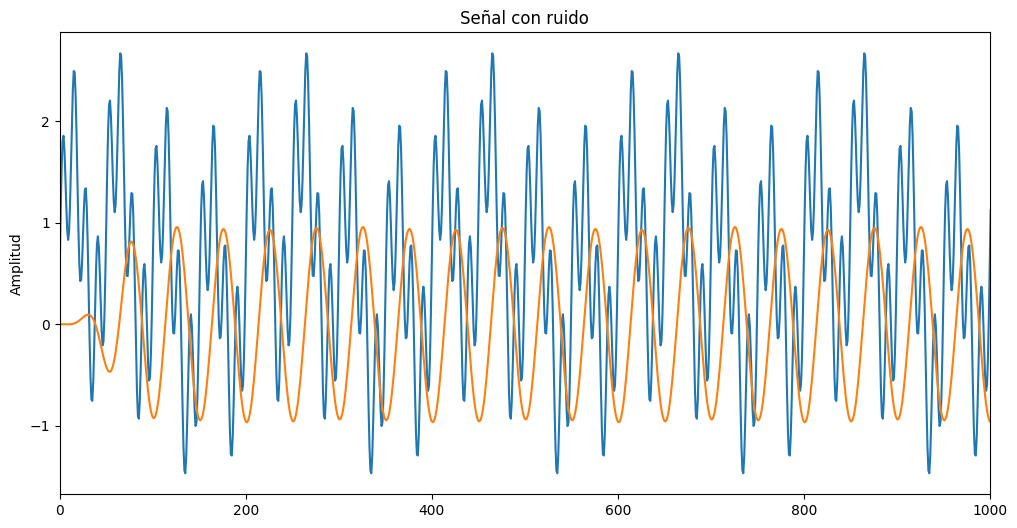

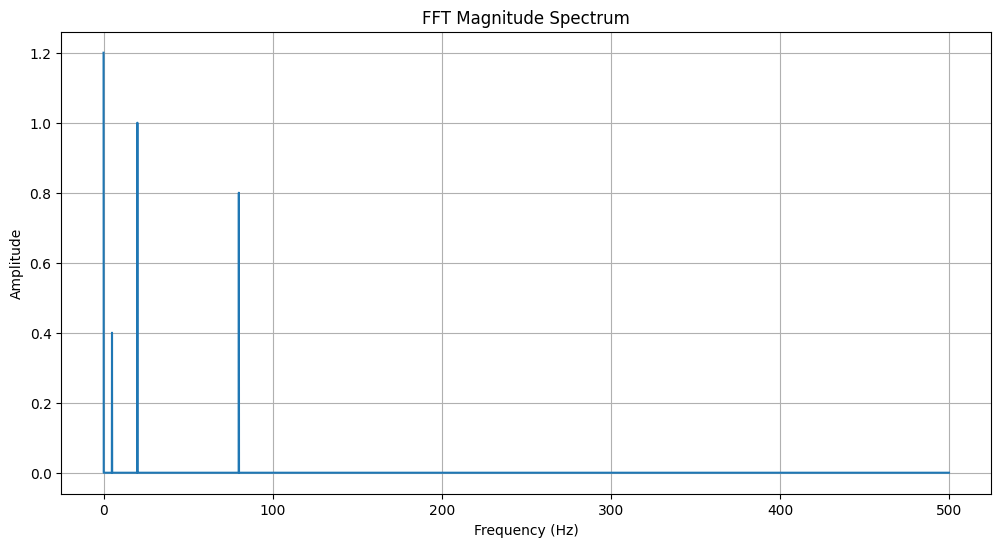

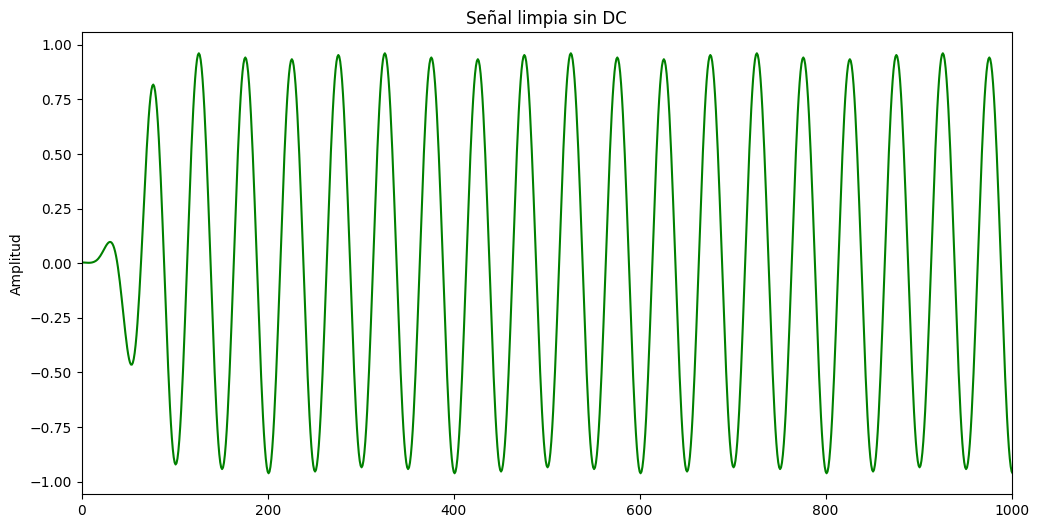

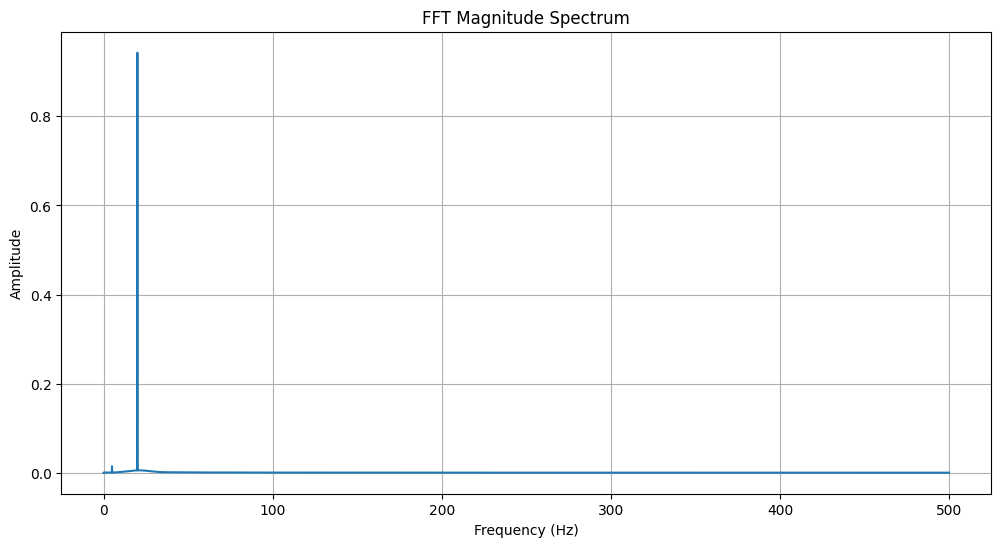

In [125]:
#SEÑAL ORIGINAL 1
n1=np.arange(len(signal1))

plt.figure(figsize=(12, 6))
plt.title('Señal con ruido')
plt.plot(n1,signal1)
plt.ylabel('Amplitud')
plt.xlim(0,1000)

plt.plot(n1,filtered)
plt.title('Señal con ruido')
plt.xlim(0,1000)

# 1. Setup
fs = 1000              # Sampling frequency (Hz)
t = np.arange(0, 10, 1/fs) # Tiempo


# 2. FFT
n = len(signal1)
yf = np.fft.fft(signal1)
xf = np.fft.fftfreq(n, 1/fs)

# 3. Visualizar
plt.figure(figsize=(12, 6))
plt.plot(xf[:n//2], 2.0/n * np.abs(yf[:n//2]))
plt.title('FFT Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

#SEÑAL LUEGO DEL FILTRADO 1
plt.figure(figsize=(12, 6))
filterednew=filtered-np.mean(filtered)
plt.ylabel('Amplitud')
plt.plot(n1,filterednew, color='green')
plt.title('Señal limpia sin DC')
plt.xlim(0,1000)

yf = np.fft.fft(filterednew)
xf = np.fft.fftfreq(n, 1/fs)

# 3. Visualization
# We only plot the positive frequencies (first half of the result)
plt.figure(figsize=(12, 6))
plt.plot(xf[:n//2], 2.0/n * np.abs(yf[:n//2]))
plt.title('FFT Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

# Ejercicio 2
ECG sintético, ruido blanco e interferencia de alta frecuencia

In [126]:
ecg2=nk.ecg_simulate(duration=10, length=None, sampling_rate=1000, noise=0.01, heart_rate=70, heart_rate_std=1, method='ecgsyn', random_state=None)
fs = 1000.0
tiempo = np.arange(0, 10, 1/fs)
ruido_blanco = np.random.normal(0, 1, len(tiempo))


Interferencia de alta freecuencia (220 Hz con amplitud=1, sin offest en DC y duración de 10 segundos)

(2000.0, 6000.0)

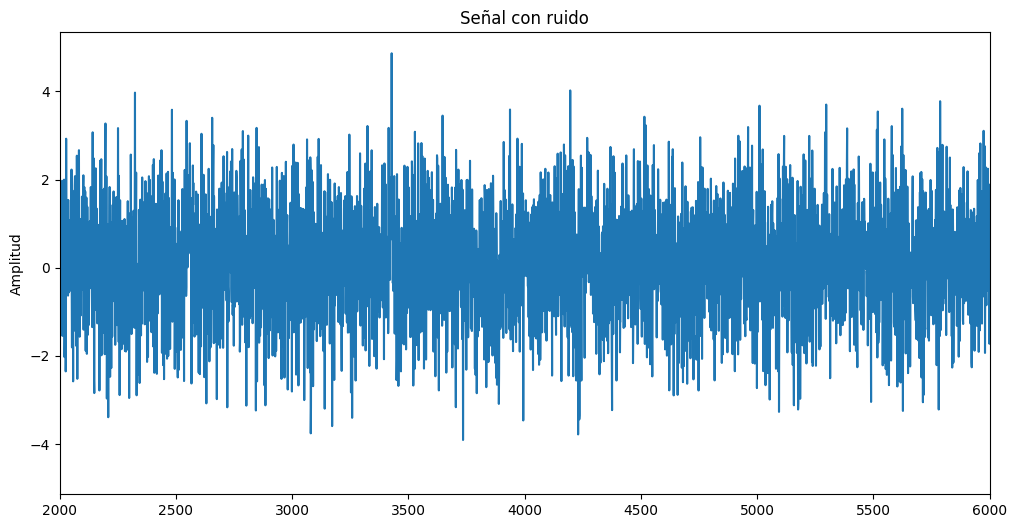

In [127]:
f1 = 220
offset1 = 0.0
amp1 = 1
interferencia = offset1 + amp1 * np.sin(2 * np.pi * f1 * t)

interferencia=ui2.signals[1]
signal2=ecg2+ruido_blanco+interferencia

n2=np.arange(len(signal2))

plt.figure(figsize=(12, 6))
plt.title('Señal con ruido')
plt.plot(n2,signal2)
plt.ylabel('Amplitud')
plt.xlim(2000,6000)


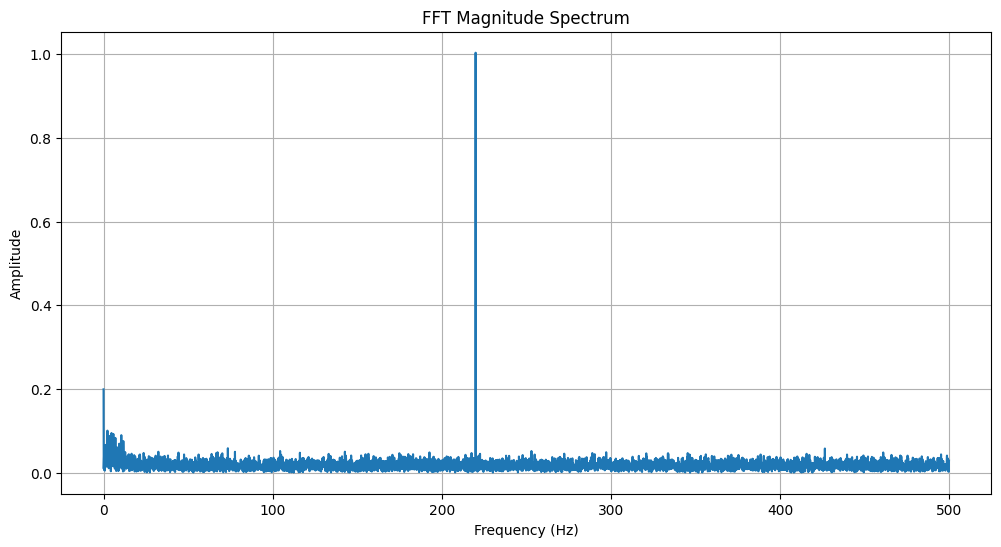

In [128]:

t = np.arange(0, 10, 1/fs) # Time vector (1 second)


# 2. FFT
n = len(signal2)
yf = np.fft.fft(signal2)
xf = np.fft.fftfreq(n, 1/fs)

# 3. Visualizar
plt.figure(figsize=(12, 6))
plt.plot(xf[:n//2], 2.0/n * np.abs(yf[:n//2]))
plt.title('FFT Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


In [129]:
#Filtros Butterworth
b, a = signal.butter(4, 40, btype='low', fs=fs)
filtered = signal.filtfilt(b, a, signal2)
d, c = signal.butter(2, 0.5, btype='high', fs=fs)
filtered = signal.filtfilt(d, c, filtered)

(2000.0, 6000.0)

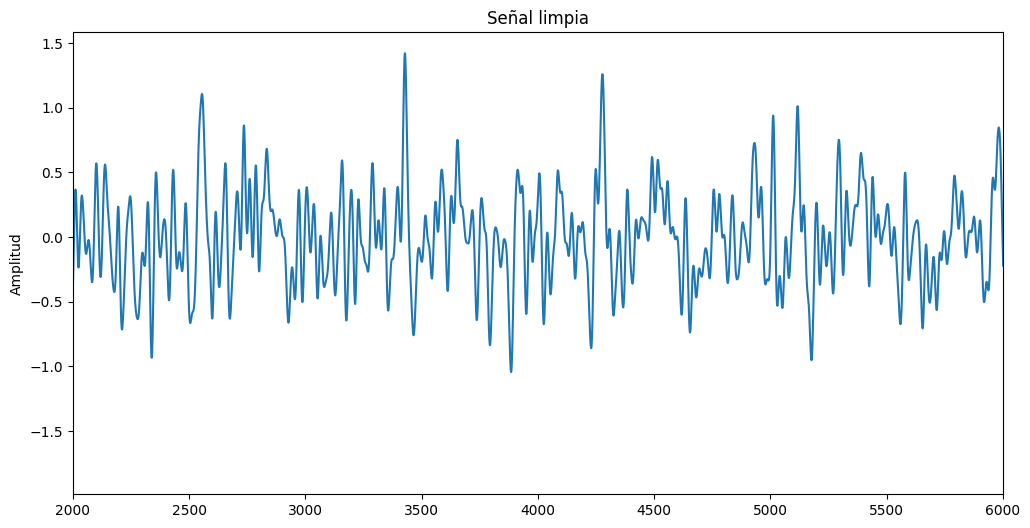

In [130]:
plt.figure(figsize=(12, 6))
plt.title('Señal limpia')
plt.plot(n2,filtered)
plt.ylabel('Amplitud')
plt.xlim(2000,6000)

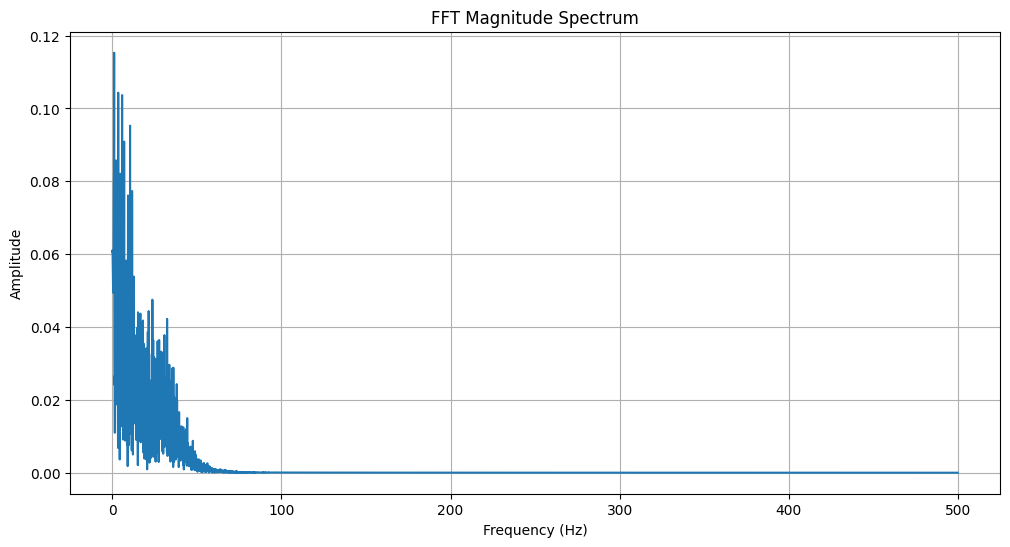

In [131]:
# 2. FFT
n = len(filtered)
yf = np.fft.fft(filtered)
xf = np.fft.fftfreq(n, 1/fs)

# 3. Visualizar
plt.figure(figsize=(12, 6))
plt.plot(xf[:n//2], 2.0/n * np.abs(yf[:n//2]))
plt.title('FFT Magnitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

## Ejercicio 3
Durante un registro EEG aparecen desconexiones instantáneas de electrodos produciendo spikes abruptos.

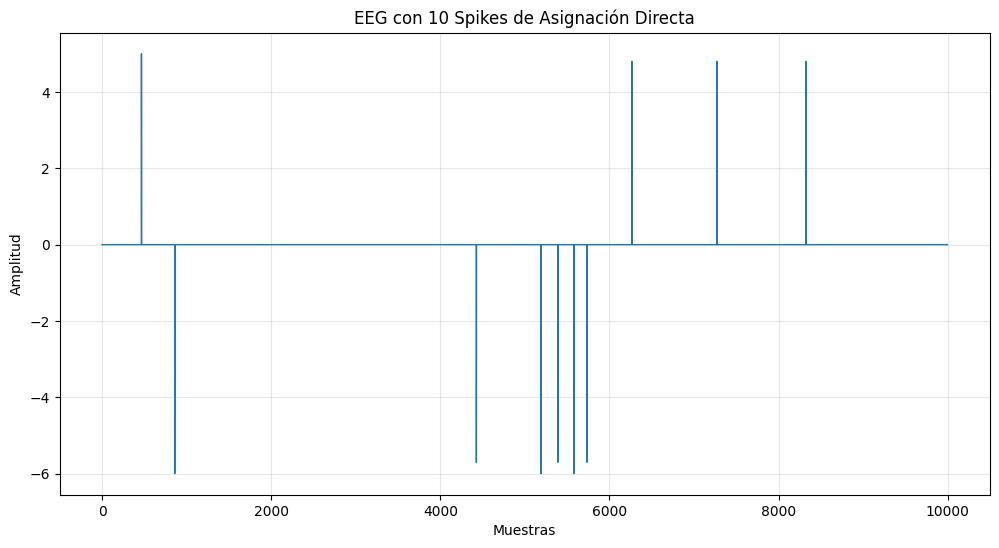

In [132]:

fs=1000
eeg= nk.eeg_simulate(duration=10, sampling_rate=fs, noise=0.05)
np.random.seed(42)
indices = np.random.randint(0, len(eeg), size=10)

for lugar in indices:
    amplitud = np.random.choice([5, -6, 4, -5.7, 4.8])
    eeg[lugar] = amplitud

#Graficar
plt.figure(figsize=(12, 6))
plt.plot(eeg, linewidth=1)
plt.title("EEG con 10 Spikes de Asignación Directa")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.show()

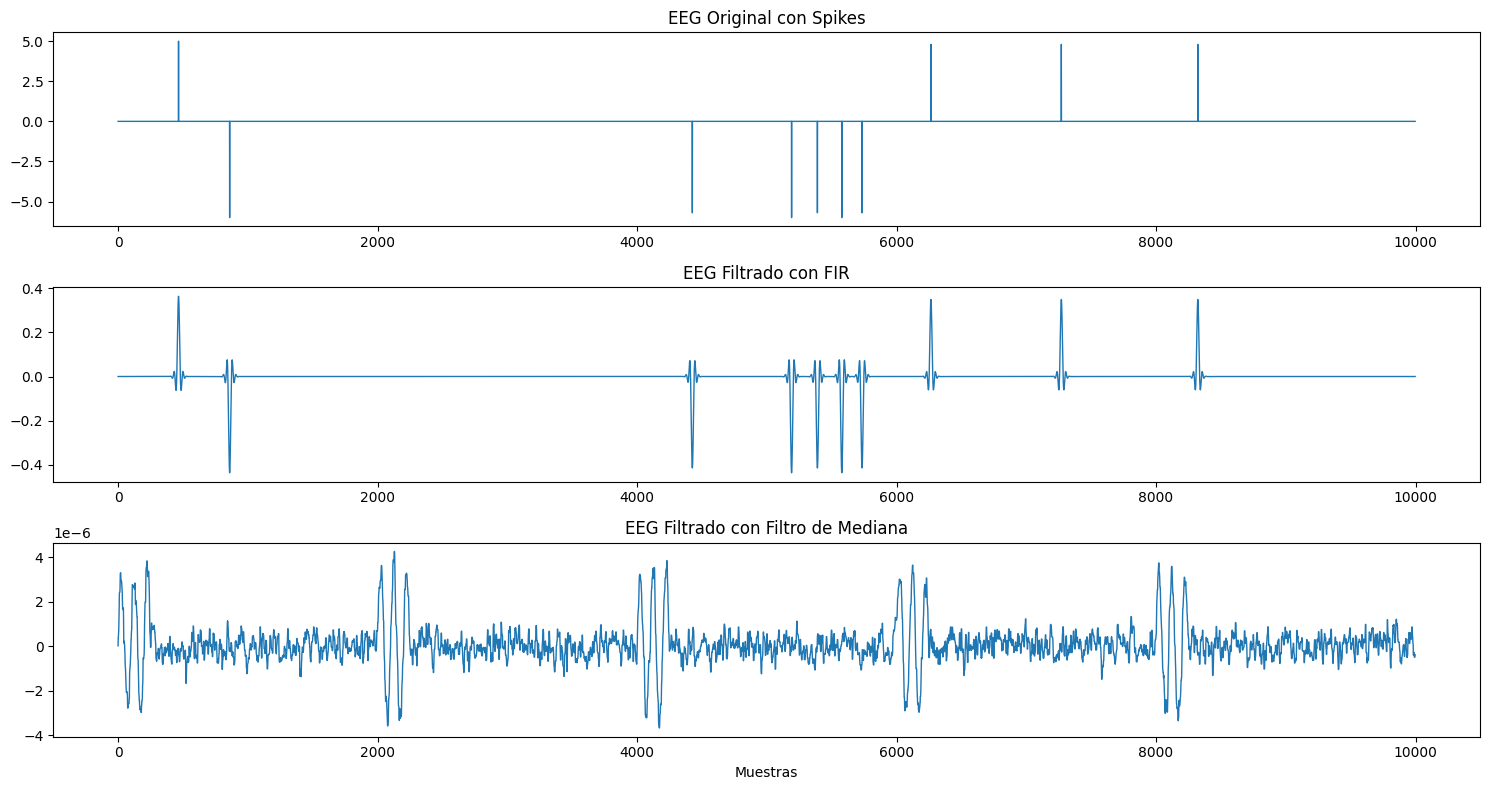

In [133]:

f_corte = 40.0  # Frecuencia de corte (40 Hz)
filter= signal.firwin(105, f_corte, window='hamming', fs=fs)

eeg_filtrado = signal.filtfilt(filter, 1.0, eeg)
eeg_med=signal.medfilt(eeg,5)

#Graficar
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(eeg, linewidth=1)
plt.title("EEG Original con Spikes")

plt.subplot(3, 1, 2)
plt.plot(eeg_filtrado, linewidth=1)
plt.title("EEG Filtrado con FIR")

plt.subplot(3, 1, 3)
plt.plot(eeg_med, linewidth=1)
plt.title("EEG Filtrado con Filtro de Mediana")
plt.xlabel("Muestras")

plt.tight_layout()
plt.show()

Explique cuál funciona mejor:
En este caso, el filtro mediana funciona mejor porque selecciona un conjunto de datos y toma su número central. En el caso de los picos, al ser eventos asilados que alteran fuertemente la señal sin un periodo fijo, el filtro mediana puede eliminarlos. Si hubiese una frecuencia determinada, FIR hubiese podido filtrar de manera más óptima.

## Ejercicio 4
Un monitor ECG hospitalario presenta interferencia causada por la red eléctrica

El pipeline a seguir será: Crear señal -> Observar componentes en frecuencia -> filtrado Notch -> filtrado de ruido blanco -> quitar componente DC -> Observar resultado y componentes en frecuencia

In [134]:
ecg3=nk.ecg_simulate(duration=10, length=None, sampling_rate=1000, noise=0.01, heart_rate=70, heart_rate_std=1, method='ecgsyn', random_state=None)
fs = 1000
tiempo = np.arange(0, 10, 1/fs)
ruido_blanco = np.random.normal(0, 1, len(tiempo))
t = np.linspace(0, 10, fs*10, endpoint=False)
r_60=2*np.sin(2 * np.pi * 60 * t)

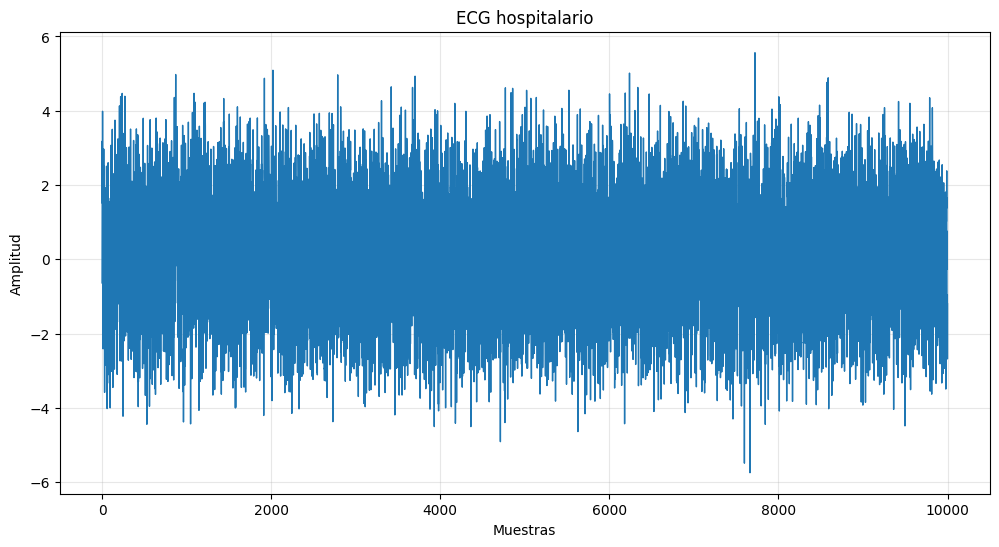

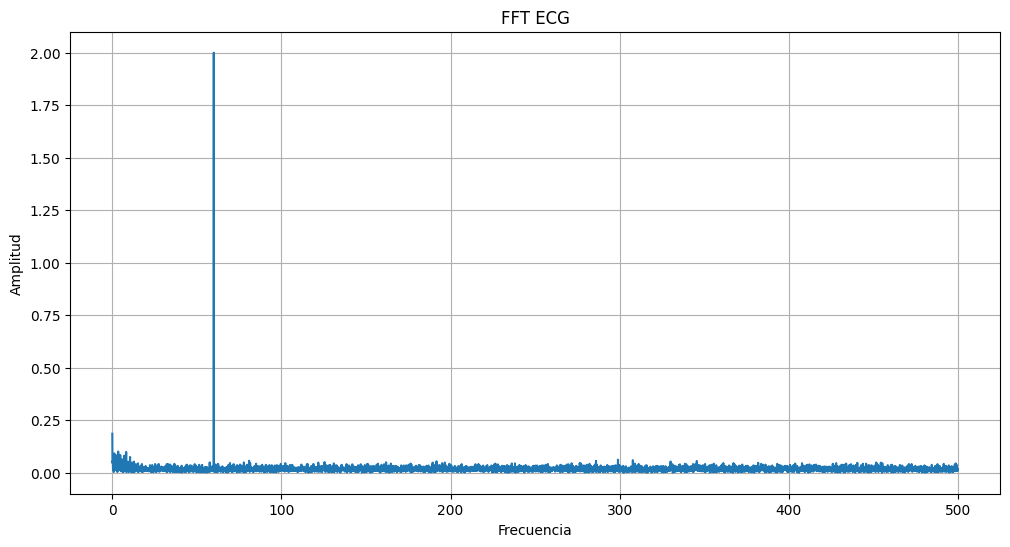

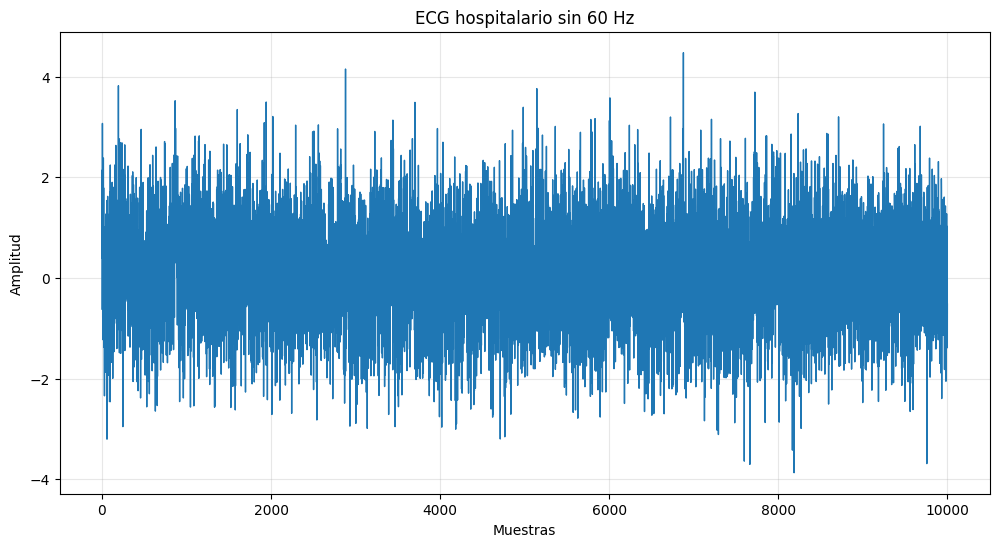

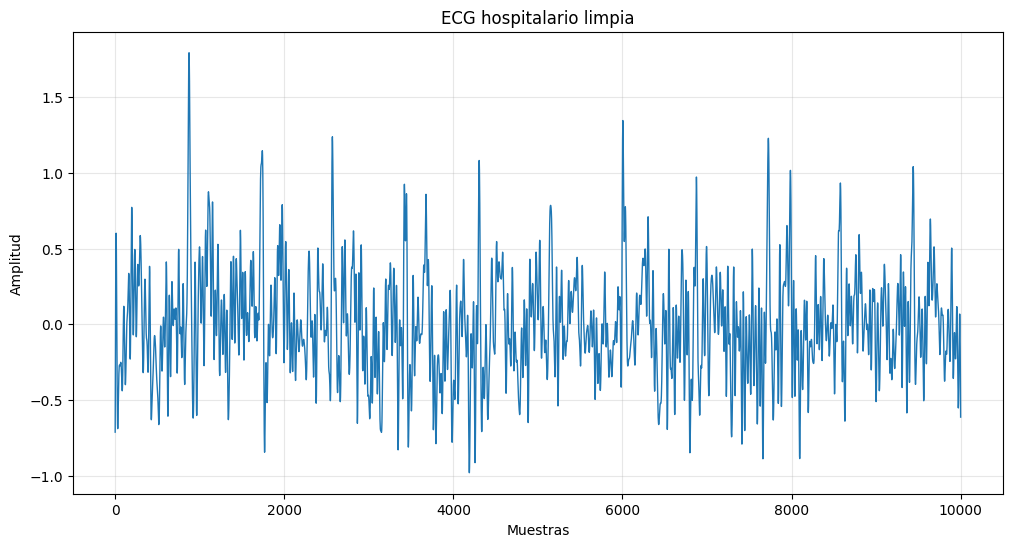

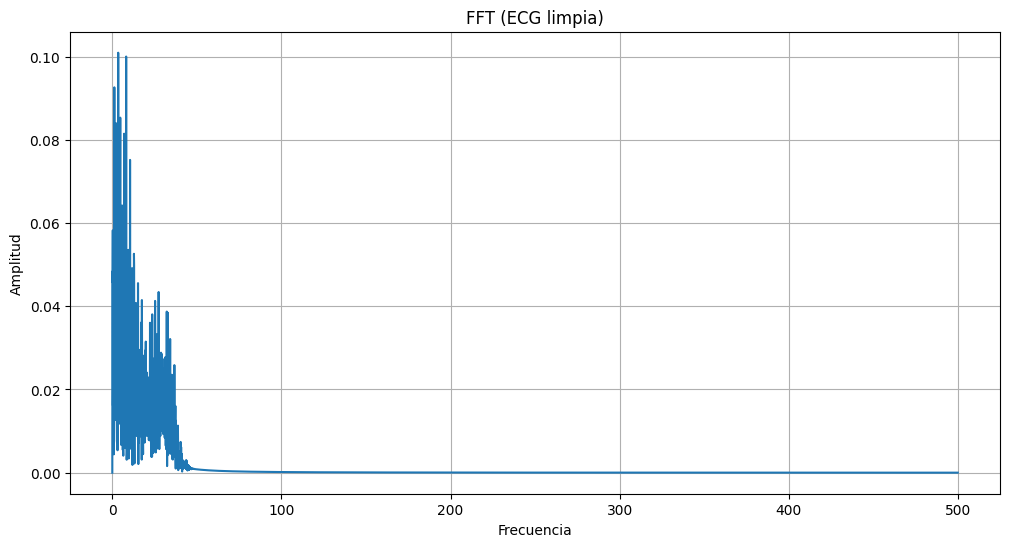

In [135]:
signal3 = ecg3 + ruido_blanco + r_60
#Graficar
plt.figure(figsize=(12, 6))
plt.plot(signal3, linewidth=1)
plt.title("ECG hospitalario")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.show()

# FFT
n = len(signal3)
yf = np.fft.fft(signal3)
xf = np.fft.fftfreq(n, 1/fs)
plt.figure(figsize=(12, 6))
plt.plot(xf[:n//2], 2.0/n * np.abs(yf[:n//2]))
plt.title('FFT ECG')
plt.xlabel('Frecuencia')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

#Eliminar r_60
b, a= signal.iirnotch(60, 30, fs)
signal3 = signal.filtfilt(b, a, signal3)

plt.figure(figsize=(12, 6))
plt.plot(signal3, linewidth=1)
plt.title("ECG hospitalario sin 60 Hz")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.show()

#Quitar ruido blanco
f_corte = 40.0
fir_coeff = signal.firwin(151, f_corte, window='hamming', fs=fs)
signal3 = signal.filtfilt(fir_coeff, 1.0, signal3)


#Quitar componente DC
signal3 = signal3 - np.mean(signal3)

#Graficar
plt.figure(figsize=(12, 6))
plt.plot(signal3, linewidth=1)
plt.title("ECG hospitalario limpia")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.show()

# FFT
n = len(signal3)
yf = np.fft.fft(signal3)
xf = np.fft.fftfreq(n, 1/fs)
plt.figure(figsize=(12, 6))
plt.plot(xf[:n//2], 2.0/n * np.abs(yf[:n//2]))
plt.title('FFT (ECG limpia)')
plt.xlabel('Frecuencia')
plt.ylabel('Amplitud')
plt.grid()
plt.show()

## Ejercicio 5
Un wearable biomédico utiliza:
ECG, respiración, acelerómetro.
Cada señal debe tener: delay distinto 2s y ruido gausiano.
Sincronice todas usando correlación cruzada.

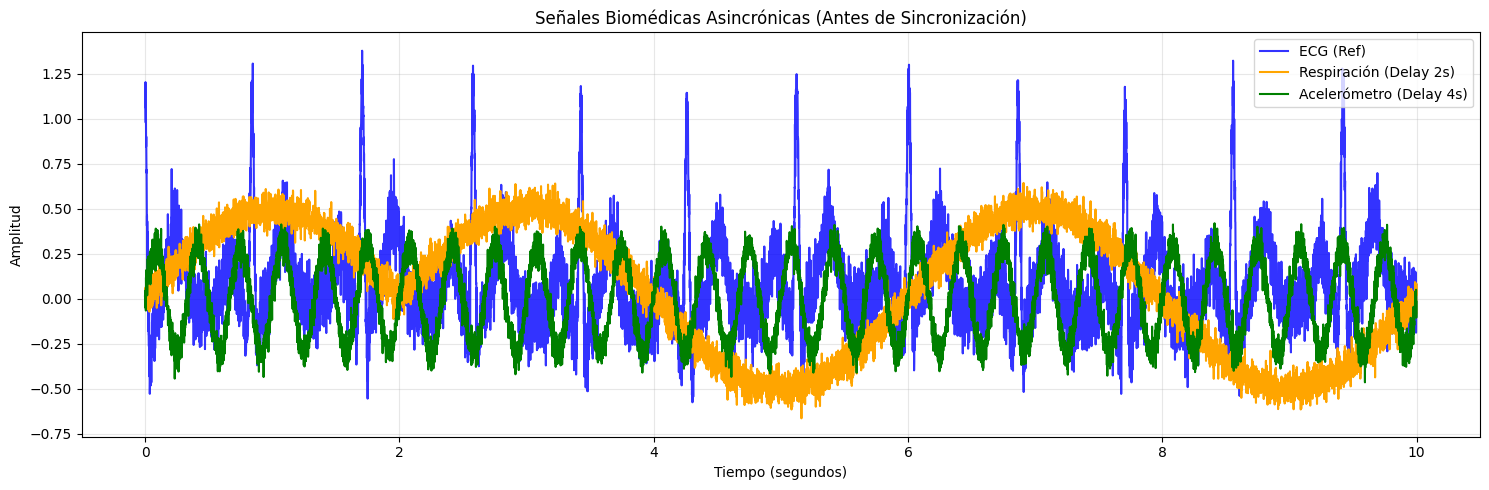

In [136]:
fs = 1000
duracion = 10  # 10 segundos
t = np.linspace(0, duracion, fs * duracion, endpoint=False)

# Canales
ecg= nk.ecg_simulate(duration=duracion, sampling_rate=fs, heart_rate=70, method='ecgsyn')
resp= 0.5 * np.sin(2 * np.pi * 0.25 * t)
acel = 0.3 * np.sin(2 * np.pi * 3 * t)

#Delays
delay_ecg= 0
delay_resp= 2
delay_acel= 4

roll_ecg = int(delay_ecg * fs)
roll_resp = int(delay_resp* fs)
roll_acel = int(delay_acel* fs)

# Desplazamientos
ecg_delayed = np.roll(ecg, roll_ecg)
resp_delayed = np.roll(resp, roll_resp)
acel_delayed = np.roll(acel, roll_acel)

# Inyección de ruido gausiano (independiente para cada canal)
np.random.seed(42)
ecg_contaminado = ecg_delayed + np.random.normal(0, 0.1, len(t))
rsp_contaminado = resp_delayed + np.random.normal(0, 0.05, len(t))
acc_contaminado = acel_delayed + np.random.normal(0, 0.05, len(t))

#Graficar
plt.figure(figsize=(15, 5))

plt.plot(t, ecg_contaminado, label="ECG (Ref)", color="blue", alpha=0.8)
plt.plot(t, rsp_contaminado, label=f"Respiración (Delay {delay_resp}s)", color="orange")
plt.plot(t, acc_contaminado, label=f"Acelerómetro (Delay {delay_acel}s)", color="green")
plt.title("Señales Biomédicas Asincrónicas (Antes de Sincronización)")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

--- RESULTADOS DE LA ESTIMACIÓN ---
Retraso Respiración  -> Teórico: 2000 muestras | Estimado: 2335 muestras (2.335 s)
Retraso Acelerómetro -> Teórico: 4000 muestras | Estimado: 1602 muestras (1.602 s)



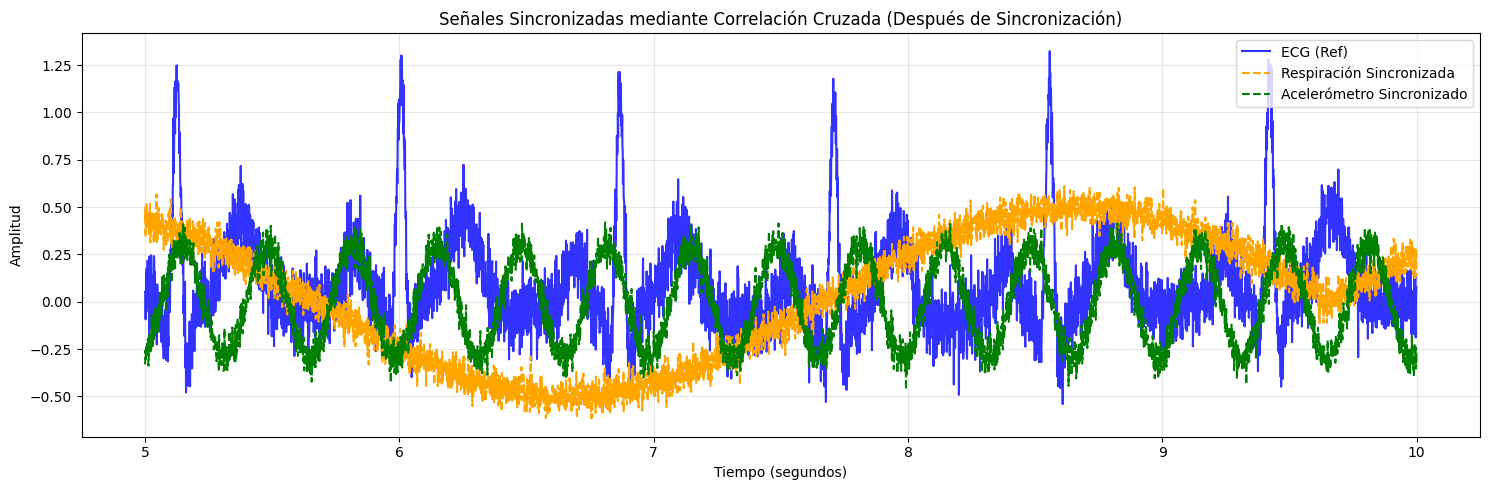

In [137]:

# Estimar las muestras de desfase entre dos canales
def calcular_desfase_muestras(canal_ref, canal_desfasado):
    corr = signal.correlate(canal_ref, canal_desfasado, mode='full')
    estimated_delay = np.argmax(corr) - len(canal_ref)
    return estimated_delay

# Calcular los retrasos
muestras_est_rsp = calcular_desfase_muestras(ecg_contaminado, rsp_contaminado)
muestras_est_acc = calcular_desfase_muestras(ecg_contaminado, acc_contaminado)

print(f"--- RESULTADOS DE LA ESTIMACIÓN ---")
print(f"Retraso Respiración  -> Teórico: {ceros_resp} muestras | Estimado: {muestras_est_rsp} muestras ({muestras_est_rsp/fs} s)")
print(f"Retraso Acelerómetro -> Teórico: {ceros_acel} muestras | Estimado: {muestras_est_acc} muestras ({muestras_est_acc/fs} s)\n")

#Alinear
ecg_sincronizado = ecg_contaminado
rsp_sincronizado = np.roll(rsp_contaminado, -muestras_est_rsp)
acc_sincronizado = np.roll(acc_contaminado, -muestras_est_acc)

#Graficar
plt.figure(figsize=(15, 5))

plt.plot(t[bloque], ecg_sincronizado[bloque], label="ECG (Ref)", color="blue", alpha=0.8)
plt.plot(t[bloque], rsp_sincronizado[bloque], label="Respiración Sincronizada", color="orange", linestyle="--")
plt.plot(t[bloque], acc_sincronizado[bloque], label="Acelerómetro Sincronizado", color="green", linestyle="--")
plt.title("Señales Sincronizadas mediante Correlación Cruzada (Después de Sincronización)")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Ejercicio 6
En una adquisición clínica:

ECG se adquiere a 500 Hz

Respiración a 100 Hz

Temperatura a 200 Hz

Se requiere fusionar todas las señales

Muestras de ECG  (500 Hz): 5000
Muestras de Resp (100 Hz): 1000
Muestras de Temp (200 Hz): 2000

Muestras de ECG  (500 Hz): 5000
Muestras de Resp (500 Hz): 5000
Muestras de Temp (500 Hz): 5000



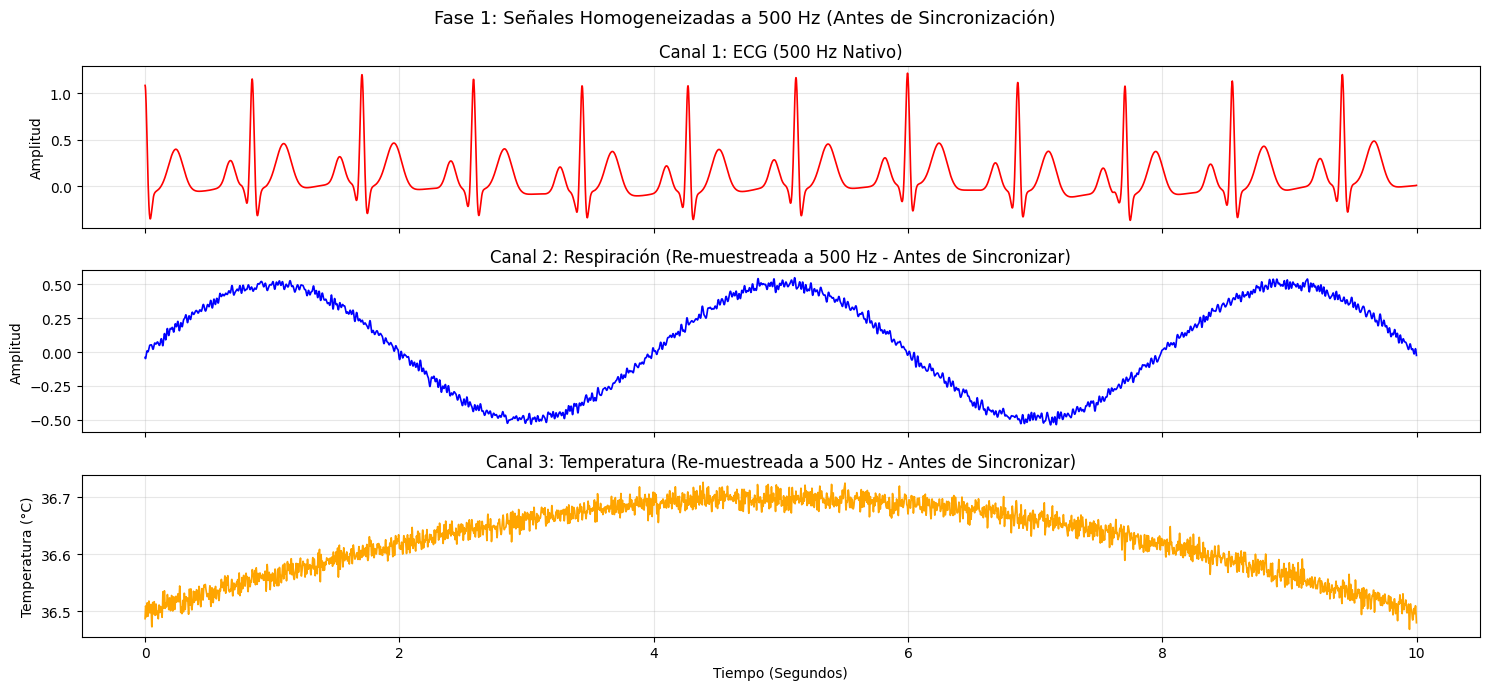

In [138]:

duracion_seg = 10

# ECG
fs_ecg = 500
t_ecg = np.linspace(0, duracion_seg, fs_ecg * duracion_seg, endpoint=False)
ecg_orig = nk.ecg_simulate(duration=duracion_seg, sampling_rate=fs_ecg, heart_rate=70, method='ecgsyn')

# Respiración
fs_resp = 100
t_resp = np.linspace(0, duracion_seg, fs_resp * duracion_seg, endpoint=False)
resp_orig = 0.5 * np.sin(2 * np.pi * 0.25 * t_resp) + np.random.normal(0, 0.02, len(t_resp))

# Temperatura
fs_temp = 200
t_temp = np.linspace(0, duracion_seg, fs_temp * duracion_seg, endpoint=False)
temp_pura = 36.5 + 0.2 * np.sin(2 * np.pi * 0.05 * t_temp)
temp_orig = temp_pura + np.random.normal(0, 0.01, len(t_temp))
print(f"Muestras de ECG  (500 Hz): {len(ecg_orig)}")
print(f"Muestras de Resp (100 Hz): {len(resp_orig)}")
print(f"Muestras de Temp (200 Hz): {len(temp_orig)}\n")


#Remuestreo (todo a 500 Hz)
fs = 500
objetivo = duracion_seg * fs

ecg= ecg_orig
resp= signal.resample(resp_orig, objetivo)
temp = signal.resample(temp_orig, objetivo)

print(f"Muestras de ECG  (500 Hz): {len(ecg)}")
print(f"Muestras de Resp (500 Hz): {len(resp)}")
print(f"Muestras de Temp (500 Hz): {len(temp)}\n")

# Graficar
fig1, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 7), sharex=True)

ax1.plot(t_ecg, ecg, color='red', linewidth=1.2)
ax1.set_title("Canal 1: ECG (500 Hz Nativo)")
ax1.grid(True, alpha=0.3)
ax1.set_ylabel("Amplitud")

ax2.plot(t_ecg, resp, color='blue', linewidth=1.2)
ax2.set_title("Canal 2: Respiración (Re-muestreada a 500 Hz - Antes de Sincronizar)")
ax2.grid(True, alpha=0.3)
ax2.set_ylabel("Amplitud")

ax3.plot(t_ecg, temp, color='orange', linewidth=1.2)
ax3.set_title("Canal 3: Temperatura (Re-muestreada a 500 Hz - Antes de Sincronizar)")
ax3.set_xlabel("Tiempo (Segundos)")
ax3.grid(True, alpha=0.3)
ax3.set_ylabel("Temperatura (°C)")

fig1.suptitle("Fase 1: Señales Homogeneizadas a 500 Hz (Antes de Sincronización)", fontsize=13)
plt.tight_layout()
plt.show()


Tiempos de retraso
Respiración  -> Estimado: 257 muestras (0.514 s)
Temperatura  -> Estimado: -89 muestras (-0.178 s)



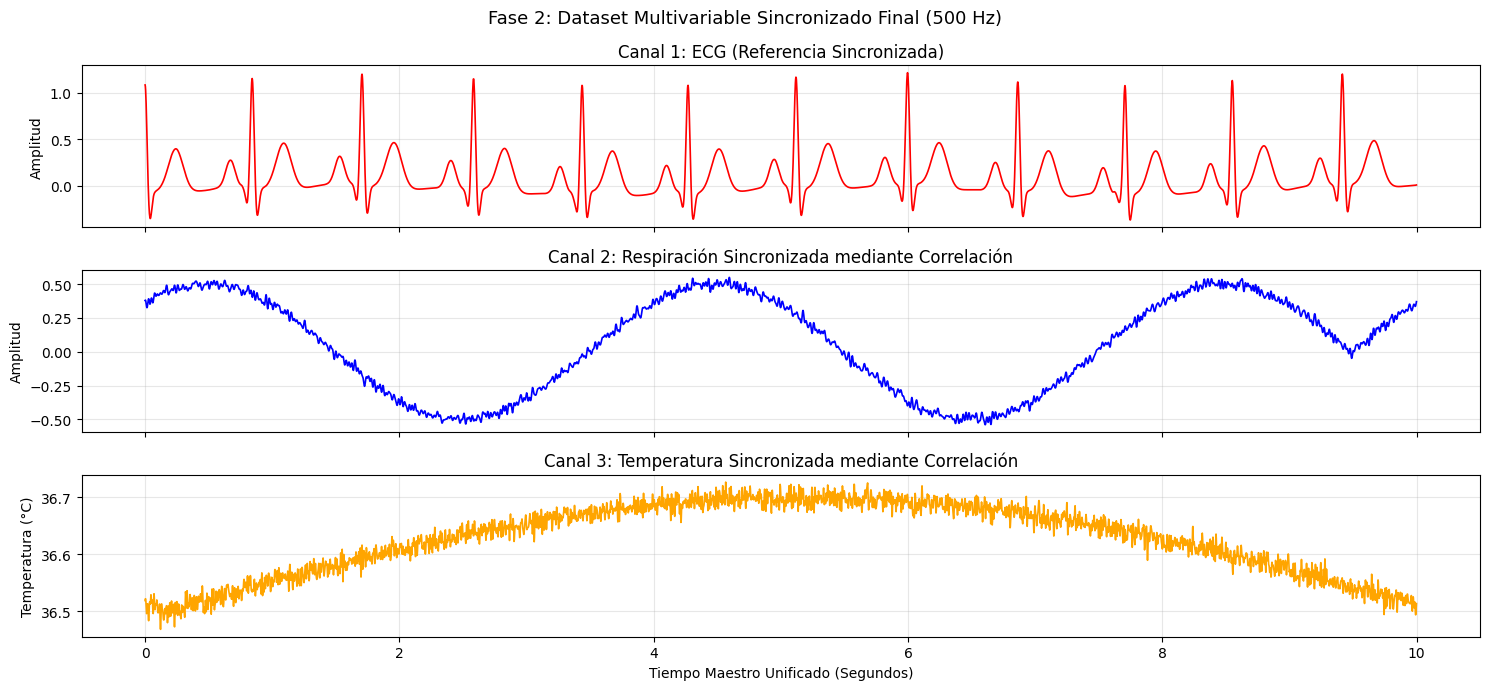

In [139]:
#Sincronizar
def calcular_desfase_muestras(canal_ref, canal_desfasado):
    corr = signal.correlate(canal_ref, canal_desfasado, mode='full')
    desfase_muestras = np.argmax(corr) - len(canal_ref)
    return desfase_muestras

muestras_est_resp = calcular_desfase_muestras(ecg, resp)
muestras_est_temp = calcular_desfase_muestras(ecg, temp)

print(f"Tiempos de retraso")
print(f"Respiración  -> Estimado: {muestras_est_resp} muestras ({muestras_est_resp/fs} s)")
print(f"Temperatura  -> Estimado: {muestras_est_temp} muestras ({muestras_est_temp/fs} s)\n")

#Alinear
resp_sincronizado = np.roll(resp, -muestras_est_resp)
temp_sincronizado = np.roll(temp, -muestras_est_temp)

#Graficar
fig2, (bx1, bx2, bx3) = plt.subplots(3, 1, figsize=(15, 7), sharex=True)

bx1.plot(t_ecg, ecg, color='red', linewidth=1.2)
bx1.set_title("Canal 1: ECG (Referencia Sincronizada)")
bx1.grid(True, alpha=0.3)
bx1.set_ylabel("Amplitud")

bx2.plot(t_ecg, resp_sincronizado, color='blue', linewidth=1.2)
bx2.set_title("Canal 2: Respiración Sincronizada mediante Correlación")
bx2.grid(True, alpha=0.3)
bx2.set_ylabel("Amplitud")

bx3.plot(t_ecg, temp_sincronizado, color='orange', linewidth=1.2)
bx3.set_title("Canal 3: Temperatura Sincronizada mediante Correlación")
bx3.set_xlabel("Tiempo Maestro Unificado (Segundos)")
bx3.grid(True, alpha=0.3)
bx3.set_ylabel("Temperatura (°C)")

fig2.suptitle("Fase 2: Dataset Multivariable Sincronizado Final (500 Hz)", fontsize=13)
plt.tight_layout()
plt.show()